Loaded NRSur7dq4EmriRemnant fit.


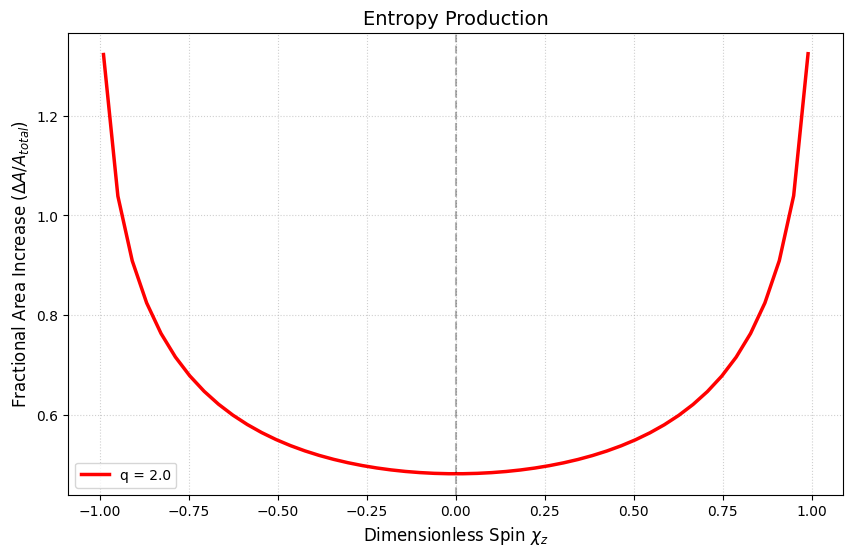

In [2]:
import surfinBH
import numpy as np
import matplotlib.pyplot as plt
import lal
lal.swig_redirect_standard_output_error(False)

fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')

def calcola_area(M, chi_vec):
    chi = np.linalg.norm(chi_vec)
    chi = min(chi, 0.99) 
    return 8 * np.pi * (M**2) * (1 + np.sqrt(1 - chi**2))


q = 2.0                     
m1, m2 = q/(1+q), 1/(1+q)  

spin_range = np.linspace(-0.99, 0.99, 50)
entropy_gain = []
valid_spins = []


for s in spin_range:
    chiA = [0, s, 0] 
    chiB = [0, s, 0]
    A_init = calcola_area(m1, chiA) + calcola_area(m2, chiB)
    res = fit.all(q, chiA, chiB)
    
    if res[0] is not None:
        mf, chif, vf, mf_err, chif_err, vf_err = res
        
        A_final = calcola_area(mf, chif)
        
        delta_A_frac = (A_final - A_init) / A_init
        
        entropy_gain.append(delta_A_frac)
        valid_spins.append(s)

plt.figure(figsize=(10, 6))
plt.plot(valid_spins, entropy_gain, color='red', linewidth=2.5, label=f'q = {q}')

plt.title('Entropy Production', fontsize=14)
plt.xlabel(r'Dimensionless Spin $\chi_z$ ', fontsize=12)
plt.ylabel(r'Fractional Area Increase ($\Delta A / A_{total}$)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()